Generating data...

--- Training Model ---
[DEPTH_RATIO] Generating 1476 sparse random projections...
Starting Clustering: Target=3 clusters.


C:\Users\Albiona Shehu\Desktop\github code\rlac.py:89: UserWarning: Computed r=1476 > n_features=50.
  warnings.warn(f"Computed r={r_dim} > n_features={n_features}.")


Iter 1: Split Cluster 0 (Size: 600) via Proj 214 | Score: 0.8542


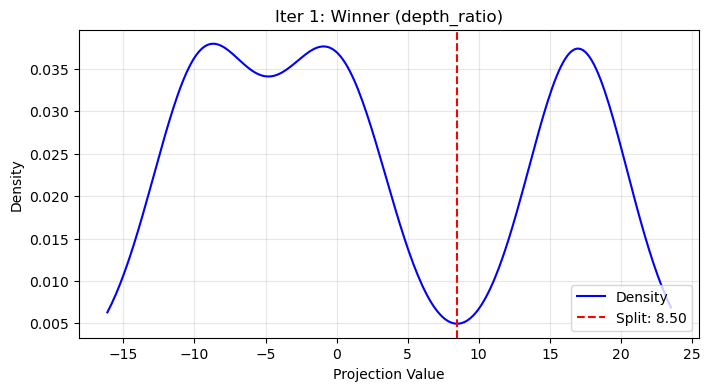

Iter 2: Split Cluster 0 (Size: 400) via Proj 807 | Score: 0.9780


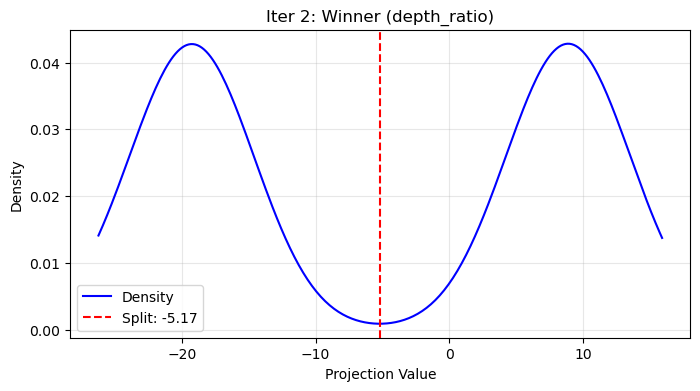

RLAC (depth_ratio) complete. Final clusters: 3

✅ Clustering Complete! Adjusted Rand Score: 1.0000


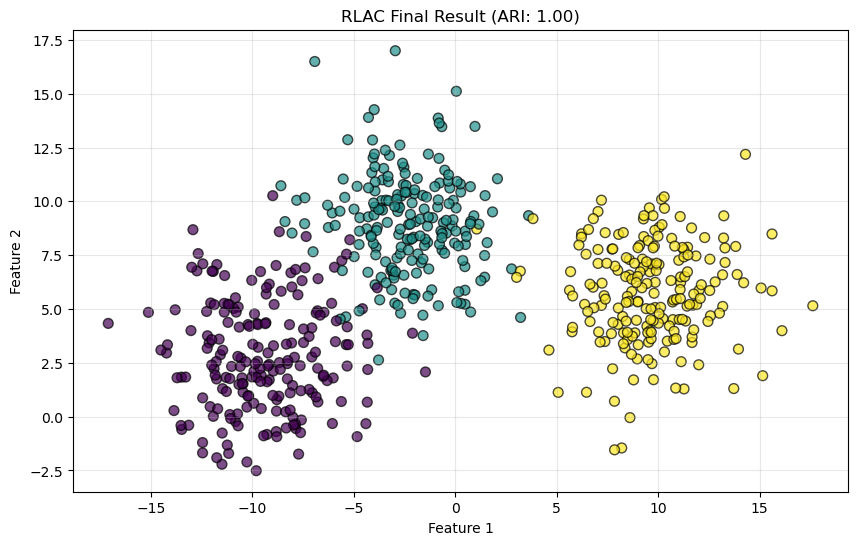

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

# If you saved the class in a separate file named rlac.py:
from rlac import RLAC 
# If the class is in the previous notebook cell, skip the import above.

# ---------------------------------------------------------
# 1. Generate Synthetic High-Dimensional Data
# ---------------------------------------------------------
# We create 3 distinct clusters in 50-dimensional space
print("Generating data...")
X, y_true = make_blobs(n_samples=600, n_features=50, centers=3, cluster_std=2.5, random_state=42)

# ---------------------------------------------------------
# 2. Initialize & Run RLAC
# ---------------------------------------------------------
# method='depth_ratio' is the original paper's metric.
# plot=True will show the Density Curve and Split Point for every decision it makes.
model = RLAC(
    n_clusters=3, 
    method='depth_ratio',  # Try 'dip', 'kurtosis', or 'depth_ratio'
    plot=True,             # Vizualize the splits in real-time
    random_state=42
)

print("\n--- Training Model ---")
model.fit(X)

# ---------------------------------------------------------
# 3. Evaluate & Visualize Final Result
# ---------------------------------------------------------
# Calculate score (1.0 is perfect match with ground truth)
score = adjusted_rand_score(y_true, model.labels_)
print(f"\n✅ Clustering Complete! Adjusted Rand Score: {score:.4f}")

# Plot the final clusters (using the first 2 dimensions for viewing)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap='viridis', edgecolor='k', s=50, alpha=0.7)
plt.title(f"RLAC Final Result (ARI: {score:.2f})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()